<div style="display: flex; align-items: center;">

  <!-- Logos -->
  <div style="white-space: nowrap;">
    <img 
      src="https://www.upc.edu/comunicacio/ca/identitat/descarrega-arxius-grafics/fitxers-marca-principal/upc-positiu-p3005.png" 
      width="300"
      style="vertical-align: middle;"
    >
    <img 
      src="https://www.hipotecalowcost.com/wp-content/uploads/2019/08/Logo-CaixaBank.png" 
      width="200"
      style="vertical-align: middle;"
    >
  </div>

  <!-- Texto -->
  <div style="margin-left: auto; margin-right: 100px; text-align: right;">
      <p style="margin: 0;"><b>CaixaBank · Advanced Analytics Program</b></p>
      <p style="margin: 0;"><b>Model Risk & Data Science Training</b></p>
      <p style="margin: 0;">Intelligence Data Science and Artificial Intelligence (IDEAI)</p>
  </div>

</div>


# 🚀 **Boosting: AdaBoost, XGBoost y CatBoost para Auditores Bancarios**


## 1. FUNDAMENTOS TEÓRICOS

Este notebook está diseñado para **auditores de un banco** que necesitan entender, construir, validar y cuestionar modelos de **Boosting** usados en riesgo de crédito, fraude, AML, scoring, early warning, churn y priorización de alertas.

El objetivo no es únicamente entrenar modelos con buen AUC, sino saber responder preguntas de auditoría como:

- ¿El modelo discrimina correctamente entre clientes buenos y malos?
- ¿Es estable en el tiempo?
- ¿Está sobreajustado?
- ¿Hay sesgos por segmento, canal, edad, zona o producto?
- ¿Las variables utilizadas son justificables desde un punto de vista regulatorio?
- ¿Puede explicarse el resultado ante Riesgos, Auditoría Interna, Cumplimiento o Supervisores?


### 1.1 ¿Qué es Boosting?

El **Boosting** es una familia de algoritmos de aprendizaje supervisado que combina muchos modelos débiles, normalmente árboles pequeños, para construir un modelo fuerte.

La idea central es:

1. Entrenar un primer modelo sencillo.
2. Identificar los errores que comete.
3. Entrenar nuevos modelos que presten más atención a esos errores.
4. Combinar todos los modelos para obtener una predicción final más potente.

En banca, Boosting se usa frecuentemente porque captura relaciones no lineales, interacciones entre variables y patrones complejos que modelos lineales como la regresión logística pueden no detectar.


### 1.2 Intuición matemática general

Un modelo de Boosting construye una función predictiva agregada:

$$F_M(x) = \sum_{m=1}^{M} \alpha_m h_m(x)$$

Donde:

- $h_m(x)$ es el modelo débil número $m$, habitualmente un árbol de decisión poco profundo.
- $\alpha_m$ es el peso o contribución de ese modelo.
- $M$ es el número total de modelos débiles.

En clasificación bancaria, la salida puede convertirse en una probabilidad de default, fraude o alerta sospechosa.


### 1.3 AdaBoost

**AdaBoost** significa *Adaptive Boosting*.

Funciona asignando más peso a las observaciones mal clasificadas. Si un cliente en default fue clasificado como bueno, en la siguiente iteración tendrá mayor importancia.

**Puntos clave para auditoría:**

| Aspecto | Interpretación |
|---|---|
| Sensibilidad a outliers | Alta. Casos extremos pueden recibir mucho peso. |
| Interpretabilidad | Media. Menos transparente que regresión logística, más simple que XGBoost. |
| Variables categóricas | Requieren codificación previa. |
| Riesgo de sobreajuste | Moderado si se usan muchos estimadores o datos ruidosos. |
| Uso típico | Benchmark, scoring simple, detección inicial de patrones. |


### 1.4 Gradient Boosting y XGBoost

**XGBoost** (*Extreme Gradient Boosting*) es una implementación optimizada de Gradient Boosting. En lugar de corregir errores mediante pesos como AdaBoost, XGBoost corrige gradualmente los residuos o gradientes de una función de pérdida.

Para clasificación binaria, minimiza una pérdida logística regularizada:

$$Obj = \sum_i l(y_i, \hat{y}_i) + \sum_k \Omega(f_k)$$

Donde:

- $l$ mide el error predictivo.
- $\Omega$ penaliza la complejidad del modelo.
- La regularización reduce el riesgo de sobreajuste.

**Puntos clave de XGBoost para banca:**

| Parámetro | Qué controla | Riesgo si se configura mal |
|---|---|---|
| `n_estimators` | Número de árboles | Demasiados árboles pueden sobreajustar. |
| `learning_rate` | Tamaño de cada paso | Alto: inestable. Bajo: requiere más árboles. |
| `max_depth` | Profundidad de árboles | Alta profundidad puede memorizar ruido. |
| `subsample` | Porcentaje de filas por árbol | Muy bajo puede infraajustar. |
| `colsample_bytree` | Porcentaje de variables por árbol | Controla robustez y correlación. |
| `scale_pos_weight` | Peso clase minoritaria | Importante en fraude/default desbalanceado. |
| `reg_alpha`, `reg_lambda` | Regularización L1/L2 | Controlan complejidad. |


### 1.5 CatBoost

**CatBoost** está especialmente diseñado para trabajar bien con variables categóricas. Es muy útil en banca porque muchos datos reales son categóricos:

- tipo de contrato,
- canal de contratación,
- provincia,
- producto,
- segmento,
- oficina,
- profesión,
- tipo de operación,
- merchant category code en fraude.

CatBoost utiliza técnicas internas para codificar categóricas reduciendo el riesgo de leakage. Aun así, desde auditoría se debe revisar cuidadosamente cómo se han definido las variables, qué información estaría disponible en el momento de decisión y si existen variables proxy de atributos sensibles.


### 1.6 Comparativa rápida

| Algoritmo | Ventajas | Riesgos / Limitaciones | Uso recomendado |
|---|---|---|---|
| AdaBoost | Simple, buen baseline, rápido | Sensible a outliers y ruido | Primer benchmark |
| XGBoost | Muy potente, regularizable, robusto | Requiere tuning, menos interpretable | Riesgo crédito, fraude, AML |
| CatBoost | Excelente con categóricas, poco preprocesado | Dependencia de librería externa, tuning propio | Datos bancarios con muchas categóricas |
| Random Forest | Robusto y fácil | Menor rendimiento en algunos problemas tabulares complejos | Benchmark paralelo |
| Regresión logística | Muy interpretable | Menor capacidad no lineal | Modelo regulatorio base / challenger |


### 1.7 Aspectos críticos para auditores bancarios

Un modelo de Boosting en banca debe auditarse en varias dimensiones:

1. **Calidad de datos:** nulos, duplicados, outliers, variables imposibles, estabilidad temporal.
2. **Definición del target:** default, fraude, sospechoso AML, mora, churn. Debe estar bien definido y no contener leakage.
3. **Leakage:** variables que contienen información futura o posterior a la decisión.
4. **Desbalanceo:** default/fraude suele ser minoritario. Accuracy puede ser engañosa.
5. **Validación temporal:** no basta con train/test aleatorio si el modelo opera en producción en meses futuros.
6. **Explicabilidad:** importancia de variables, SHAP, PDP, segmentación de errores.
7. **Fairness:** revisar diferencias de rendimiento por grupos y proxies sensibles.
8. **Estabilidad:** PSI, drift de variables, caída de AUC, cambios en distribución de score.
9. **Gobernanza:** documentación, versionado, responsables, aprobación, monitorización.
10. **Uso del modelo:** aprobar/rechazar, priorizar alertas, definir límites, pricing o revisión manual.


### 1.8 Métricas clave en banca

| Métrica | Uso | Interpretación |
|---|---|---|
| AUC-ROC | Discriminación global | 0.5 aleatorio, 1.0 perfecto |
| Gini | Estándar en crédito | Gini = 2 × AUC − 1 |
| KS | Separación buenos/malos | Muy usado en scoring bancario |
| Precision | Alertas realmente positivas | Clave si investigar alertas cuesta dinero |
| Recall / Sensibilidad | Positivos detectados | Clave en fraude y AML |
| F1-score | Balance precision-recall | Útil con desbalanceo |
| PR-AUC | Rendimiento con clase rara | Más informativo que ROC si hay mucho desbalance |
| Brier Score | Calidad probabilística | Menor es mejor |
| PSI | Estabilidad poblacional | Mide drift de score o variables |


## 2. CONFIGURACIÓN Y LIBRERÍAS


In [2]:
# Instalación de librerías necesarias
# Ejecuta estas líneas si alguna librería no está instalada en tu entorno.
# !pip install scikit-learn pandas numpy matplotlib seaborn
# !pip install xgboost catboost shap

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score, accuracy_score,
    precision_score, recall_score, f1_score, brier_score_loss
)
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

# Intentamos importar XGBoost y CatBoost. Si no están instalados, el notebook sigue funcionando con alternativas.
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except Exception as e:
    XGBOOST_AVAILABLE = False
    print('⚠️ XGBoost no está instalado. Se usará GradientBoosting/HistGradientBoosting como alternativa.')

try:
    from catboost import CatBoostClassifier
    CATBOOST_AVAILABLE = True
except Exception as e:
    CATBOOST_AVAILABLE = False
    print('⚠️ CatBoost no está instalado. Se usará OneHotEncoder + GradientBoosting como alternativa.')

np.random.seed(42)
pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid')


## 3. FUNCIONES AUXILIARES DE AUDITORÍA


In [4]:
def ks_statistic(y_true, y_score):
    """Calcula el estadístico Kolmogorov-Smirnov para clasificación binaria."""
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    ks = np.max(tpr - fpr)
    threshold_ks = thresholds[np.argmax(tpr - fpr)]
    return ks, threshold_ks


def gini_from_auc(auc):
    return 2 * auc - 1


def evaluar_modelo(nombre, modelo, X_test, y_test, threshold=0.5):
    """Evalúa un modelo binario con métricas habituales en banca."""
    if hasattr(modelo, 'predict_proba'):
        y_score = modelo.predict_proba(X_test)[:, 1]
    else:
        y_score = modelo.decision_function(X_test)
        y_score = (y_score - y_score.min()) / (y_score.max() - y_score.min())

    y_pred = (y_score >= threshold).astype(int)
    auc = roc_auc_score(y_test, y_score)
    ks, thr_ks = ks_statistic(y_test, y_score)
    ap = average_precision_score(y_test, y_score)
    brier = brier_score_loss(y_test, y_score)

    return pd.DataFrame({
        'modelo': [nombre],
        'threshold': [threshold],
        'AUC': [auc],
        'Gini': [gini_from_auc(auc)],
        'KS': [ks],
        'threshold_KS': [thr_ks],
        'PR_AUC': [ap],
        'Accuracy': [accuracy_score(y_test, y_pred)],
        'Precision': [precision_score(y_test, y_pred, zero_division=0)],
        'Recall': [recall_score(y_test, y_pred, zero_division=0)],
        'F1': [f1_score(y_test, y_pred, zero_division=0)],
        'Brier': [brier]
    })


def plot_roc_pr(y_true, scores_dict):
    """Grafica ROC y Precision-Recall para varios modelos."""
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    for nombre, y_score in scores_dict.items():
        fpr, tpr, _ = roc_curve(y_true, y_score)
        auc = roc_auc_score(y_true, y_score)
        axes[0].plot(fpr, tpr, label=f'{nombre} AUC={auc:.3f}')

        precision, recall, _ = precision_recall_curve(y_true, y_score)
        ap = average_precision_score(y_true, y_score)
        axes[1].plot(recall, precision, label=f'{nombre} PR-AUC={ap:.3f}')

    axes[0].plot([0,1], [0,1], linestyle='--', color='black')
    axes[0].set_title('Curva ROC')
    axes[0].set_xlabel('False Positive Rate')
    axes[0].set_ylabel('True Positive Rate')
    axes[0].legend()

    axes[1].set_title('Curva Precision-Recall')
    axes[1].set_xlabel('Recall')
    axes[1].set_ylabel('Precision')
    axes[1].legend()
    plt.show()


def calcular_psi(expected, actual, buckets=10):
    """Calcula PSI entre una distribución esperada y una actual."""
    expected = pd.Series(expected).dropna()
    actual = pd.Series(actual).dropna()
    quantiles = np.linspace(0, 1, buckets + 1)
    bins = np.unique(np.quantile(expected, quantiles))
    if len(bins) <= 2:
        bins = np.linspace(expected.min(), expected.max(), buckets + 1)
    bins[0] = -np.inf
    bins[-1] = np.inf
    expected_counts = pd.cut(expected, bins=bins, include_lowest=True).value_counts(normalize=True).sort_index()
    actual_counts = pd.cut(actual, bins=bins, include_lowest=True).value_counts(normalize=True).sort_index()
    psi_df = pd.DataFrame({'expected': expected_counts, 'actual': actual_counts})
    psi_df = psi_df.replace(0, 0.0001)
    psi_df['psi'] = (psi_df['actual'] - psi_df['expected']) * np.log(psi_df['actual'] / psi_df['expected'])
    return psi_df['psi'].sum(), psi_df


## 4. LECTURA / GENERACIÓN DE DATOS BANCARIOS


In [5]:
from pathlib import Path

def generar_datos_auditoria_bancaria(n=8000, random_state=42):
    """Genera datos sintéticos con la misma estructura que el CSV nuevo de auditoría bancaria."""
    rng = np.random.default_rng(random_state)

    importe_operacion = rng.lognormal(mean=7.4, sigma=1.05, size=n).clip(10, 250000)
    saldo_medio_cliente = rng.lognormal(mean=9.2, sigma=1.0, size=n).clip(100, 1_500_000)
    num_operaciones_30d = rng.poisson(18, n).clip(0, 160)
    importe_total_30d = (importe_operacion * rng.uniform(1.5, 9.0, n) + rng.lognormal(8.5, 0.8, n)).clip(100, 2_500_000)
    antiguedad_cliente_meses = rng.exponential(72, n).clip(1, 420)
    score_crediticio = rng.normal(665, 85, n).clip(300, 850)
    ratio_ingresos_deuda = rng.beta(2.2, 5.0, n).clip(0.01, 0.98)
    num_alertas_previas = rng.poisson(0.7, n).clip(0, 12)
    dias_desde_ultima_revision = rng.exponential(85, n).clip(0, 540)
    porcentaje_operaciones_internacionales = rng.beta(1.2, 8.0, n).clip(0, 1)

    canal_operacion = rng.choice(['oficina', 'web', 'app', 'telefono', 'cajero'], n, p=[0.30, 0.24, 0.28, 0.10, 0.08])
    tipo_cliente = rng.choice(['particular', 'autonomo', 'empresa', 'banca_privada'], n, p=[0.63, 0.17, 0.16, 0.04])
    pais_riesgo = rng.choice(['bajo', 'medio', 'alto'], n, p=[0.74, 0.20, 0.06])
    producto = rng.choice(['cuenta_corriente', 'tarjeta', 'prestamo_personal', 'hipoteca', 'inversion', 'pyme'], n,
                          p=[0.28, 0.20, 0.18, 0.14, 0.10, 0.10])
    segmento_riesgo_cliente = rng.choice(['bajo', 'medio', 'alto'], n, p=[0.58, 0.32, 0.10])

    z = (
        -4.2
        + 0.000006 * importe_operacion
        + 0.0000012 * importe_total_30d
        + 2.4 * ratio_ingresos_deuda
        + 0.34 * num_alertas_previas
        + 0.0032 * dias_desde_ultima_revision
        + 2.3 * porcentaje_operaciones_internacionales
        - 0.0045 * score_crediticio
        - 0.004 * antiguedad_cliente_meses
        + np.where(canal_operacion == 'web', 0.18, 0)
        + np.where(canal_operacion == 'app', 0.10, 0)
        + np.where(tipo_cliente == 'empresa', 0.28, 0)
        + np.where(tipo_cliente == 'autonomo', 0.22, 0)
        + np.where(pais_riesgo == 'medio', 0.65, 0)
        + np.where(pais_riesgo == 'alto', 1.35, 0)
        + np.where(producto == 'prestamo_personal', 0.45, 0)
        + np.where(producto == 'pyme', 0.40, 0)
        + np.where(segmento_riesgo_cliente == 'medio', 0.55, 0)
        + np.where(segmento_riesgo_cliente == 'alto', 1.25, 0)
    )

    p = 1 / (1 + np.exp(-z))
    # Mantener una clase positiva minoritaria, como suele ocurrir en auditoría.
    p = np.clip(p * 0.9, 0.002, 0.75)
    riesgo_auditoria = rng.binomial(1, p)

    return pd.DataFrame({
        'id_operacion': np.arange(1, n + 1),
        'importe_operacion': importe_operacion.round(2),
        'saldo_medio_cliente': saldo_medio_cliente.round(2),
        'num_operaciones_30d': num_operaciones_30d,
        'importe_total_30d': importe_total_30d.round(2),
        'antiguedad_cliente_meses': antiguedad_cliente_meses.round(1),
        'score_crediticio': score_crediticio.round(0),
        'ratio_ingresos_deuda': ratio_ingresos_deuda.round(3),
        'num_alertas_previas': num_alertas_previas,
        'dias_desde_ultima_revision': dias_desde_ultima_revision.round(1),
        'porcentaje_operaciones_internacionales': porcentaje_operaciones_internacionales.round(3),
        'canal_operacion': canal_operacion,
        'tipo_cliente': tipo_cliente,
        'pais_riesgo': pais_riesgo,
        'producto': producto,
        'segmento_riesgo_cliente': segmento_riesgo_cliente,
        'riesgo_auditoria': riesgo_auditoria
    })


CSV_PATH = Path('../../data/auditoria_bancaria_desbalanceada.csv')
if not CSV_PATH.exists():
    CSV_PATH = Path('/mnt/data/auditoria_bancaria_desbalanceada.csv')

if CSV_PATH.exists():
    df = pd.read_csv(CSV_PATH)
    print(f'CSV cargado correctamente desde: {CSV_PATH}')
else:
    print("No se encontró el CSV. Se genera un dataset sintético compatible.")
    df = generar_datos_auditoria_bancaria(n=15000, random_state=42)

TARGET = 'riesgo_auditoria'
ID_COLS = [c for c in ['id_operacion'] if c in df.columns]

print(df.shape)
df.head()

CSV cargado correctamente desde: ..\..\data\auditoria_bancaria_desbalanceada.csv
(15000, 17)


,id_operacion,importe_operacion,saldo_medio_cliente,num_operaciones_30d,importe_total_30d,antiguedad_cliente_meses,score_crediticio,ratio_ingresos_deuda,num_alertas_previas,dias_desde_ultima_revision,porcentaje_operaciones_internacionales,canal_operacion,tipo_cliente,pais_riesgo,producto,segmento_riesgo_cliente,riesgo_auditoria
0,1,233.39,11739.05,17,3085.27,25.0,763.0,0.309,1,31.0,0.003,oficina,particular,bajo,prestamo,medio,0
1,2,829.72,411.47,15,10457.08,80.0,665.0,0.248,1,37.0,0.007,web,particular,bajo,transferencia,medio,0
2,3,176.14,2928.34,23,5525.19,21.0,610.0,0.257,0,269.0,0.439,cajero,particular,alto,tarjeta,medio,1
3,4,2141.27,3579.99,16,2347.29,71.0,776.0,0.211,0,326.0,0.120,web,pyme,bajo,cuenta,alto,0
4,5,1039.73,1938.84,16,9070.86,27.0,626.0,0.278,0,150.0,0.179,app,particular,bajo,cuenta,bajo,0


## 5. ANÁLISIS EXPLORATORIO DE DATOS


In [6]:
print('DIMENSIONES DEL DATASET')
print('='*50)
print(df.shape)
print('\nTasa de riesgo de auditoría:', round(df[TARGET].mean()*100, 2), '%')
df.describe(include='all').T.head(25)


DIMENSIONES DEL DATASET
(15000, 17)

Tasa de riesgo de auditoría: 6.32 %


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id_operacion,15000.0,NaN,NaN,NaN,7500.5,4330.271354,1.0,3750.75,7500.5,11250.25,15000.0
importe_operacion,15000.0,NaN,NaN,NaN,1459.922872,2694.705284,5.0,333.5425,732.075,1610.82,143318.97
saldo_medio_cliente,15000.0,NaN,NaN,NaN,9824.272609,12503.778828,122.35,3075.8975,5977.365,11731.4875,245519.52
num_operaciones_30d,15000.0,NaN,NaN,NaN,17.932133,4.251047,4.0,15.0,18.0,21.0,36.0
importe_total_30d,15000.0,NaN,NaN,NaN,11404.111911,22673.629097,0.0,2147.5525,5563.94,12193.9825,904093.21
antiguedad_cliente_meses,15000.0,NaN,NaN,NaN,62.7016,33.827017,3.0,38.0,57.0,81.0,292.0
score_crediticio,15000.0,NaN,NaN,NaN,680.3012,85.030305,356.0,623.0,680.0,738.0,900.0
ratio_ingresos_deuda,15000.0,NaN,NaN,NaN,0.285775,0.152676,0.005,0.168,0.266,0.384,0.866
num_alertas_previas,15000.0,NaN,NaN,NaN,0.445,0.661265,0.0,0.0,0.0,1.0,4.0
dias_desde_ultima_revision,15000.0,NaN,NaN,NaN,107.889667,107.334137,1.0,32.0,75.0,151.0,900.0


In [7]:
print('VALORES NULOS')
print('='*50)
nulos = df.isnull().sum()
print(nulos[nulos > 0] if nulos.sum() > 0 else '✅ No hay valores nulos')

print('\nDUPLICADOS')
print('='*50)
if 'id_operacion' in df.columns:
    print('Duplicados por id_operacion:', df['id_operacion'].duplicated().sum())
else:
    print('No existe columna identificadora id_operacion.')


VALORES NULOS
✅ No hay valores nulos

DUPLICADOS
Duplicados por id_operacion: 0


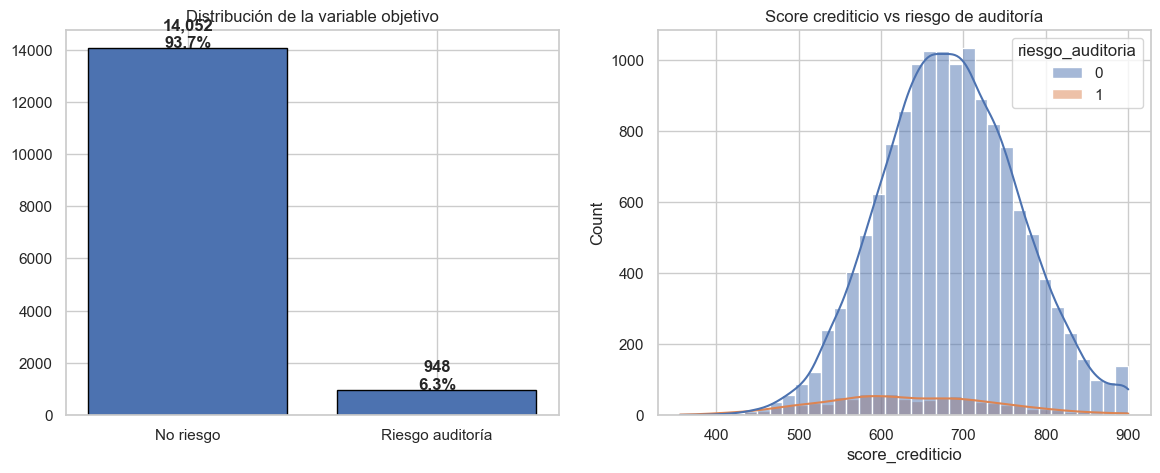

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
conteos = df[TARGET].value_counts().sort_index()
axes[0].bar(['No riesgo', 'Riesgo auditoría'], conteos.values, edgecolor='black')
for i, v in enumerate(conteos.values):
    axes[0].text(i, v + 30, f'{v:,}\n{v/len(df)*100:.1f}%', ha='center', fontweight='bold')
axes[0].set_title('Distribución de la variable objetivo')

sns.histplot(data=df, x='score_crediticio', hue=TARGET, bins=35, kde=True, ax=axes[1])
axes[1].set_title('Score crediticio vs riesgo de auditoría')
plt.show()


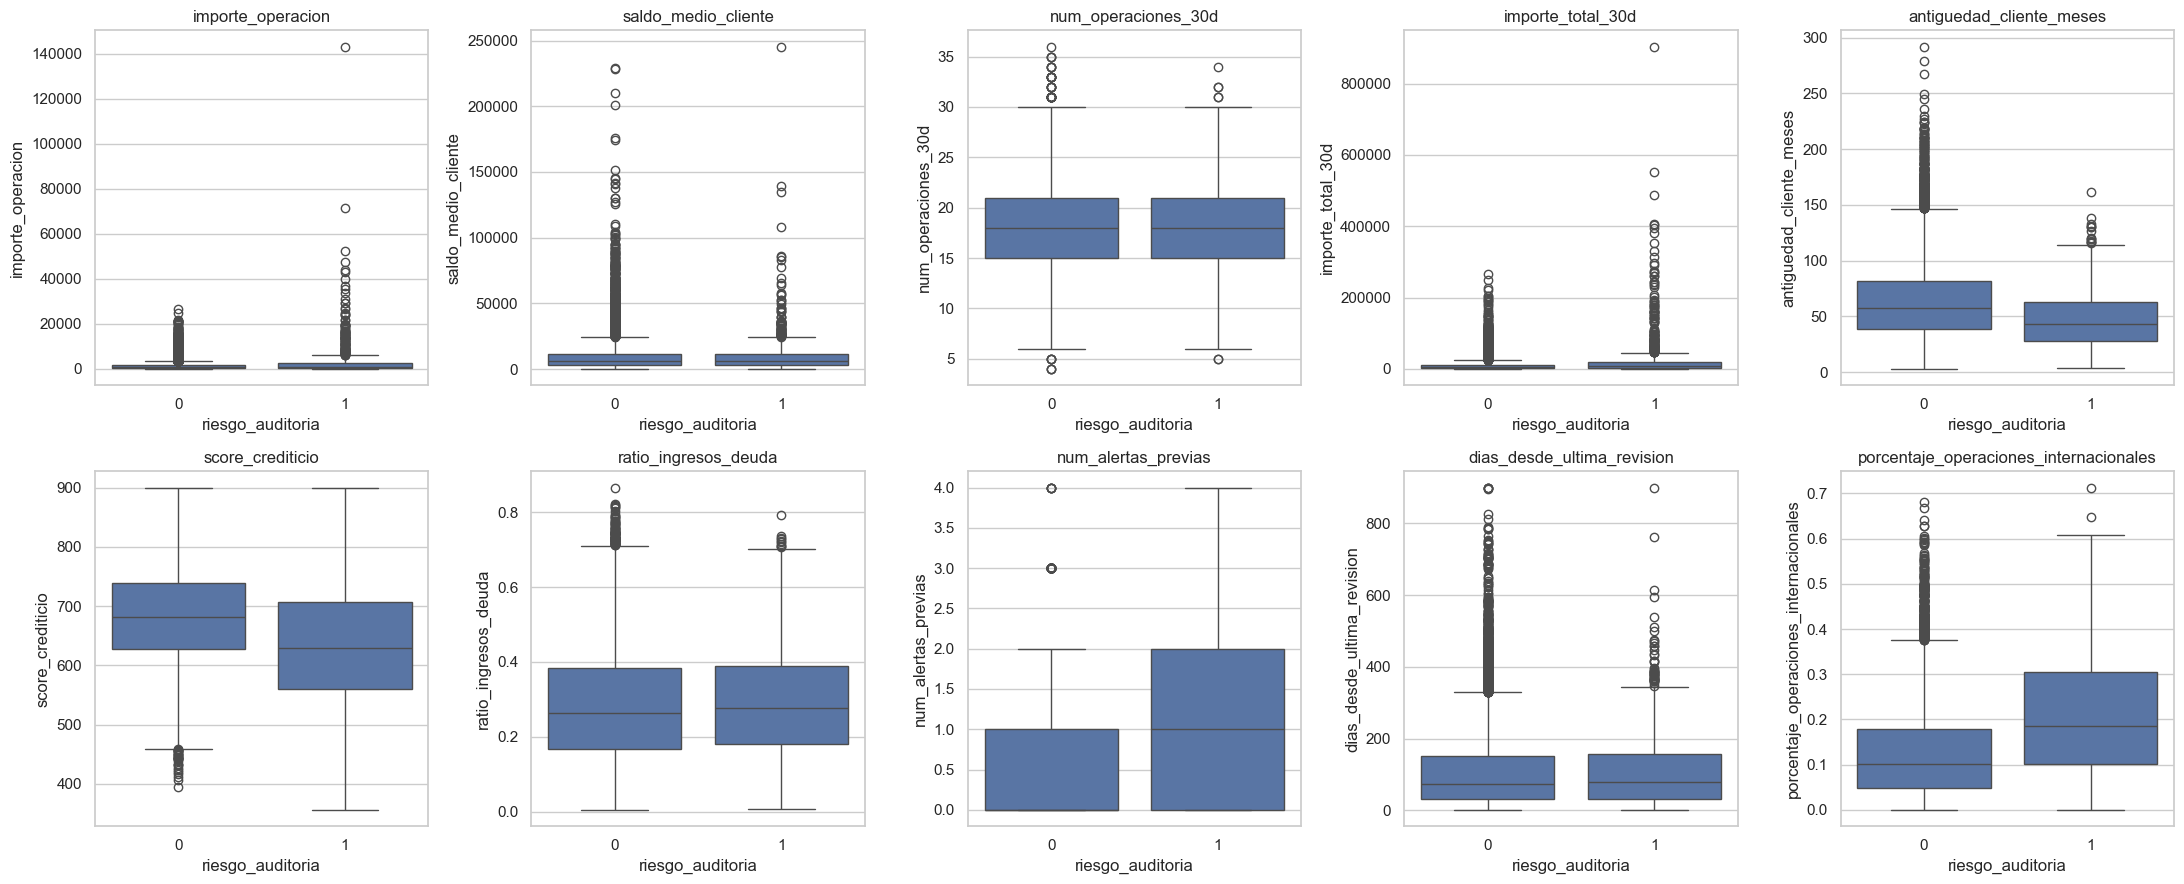

In [9]:
vars_num = [
    'importe_operacion', 'saldo_medio_cliente', 'num_operaciones_30d',
    'importe_total_30d', 'antiguedad_cliente_meses', 'score_crediticio',
    'ratio_ingresos_deuda', 'num_alertas_previas',
    'dias_desde_ultima_revision', 'porcentaje_operaciones_internacionales'
]

fig, axes = plt.subplots(2, 5, figsize=(22, 9))
axes = axes.flatten()
for i, var in enumerate(vars_num):
    sns.boxplot(data=df, x=TARGET, y=var, ax=axes[i])
    axes[i].set_title(var)
plt.tight_layout()
plt.show()


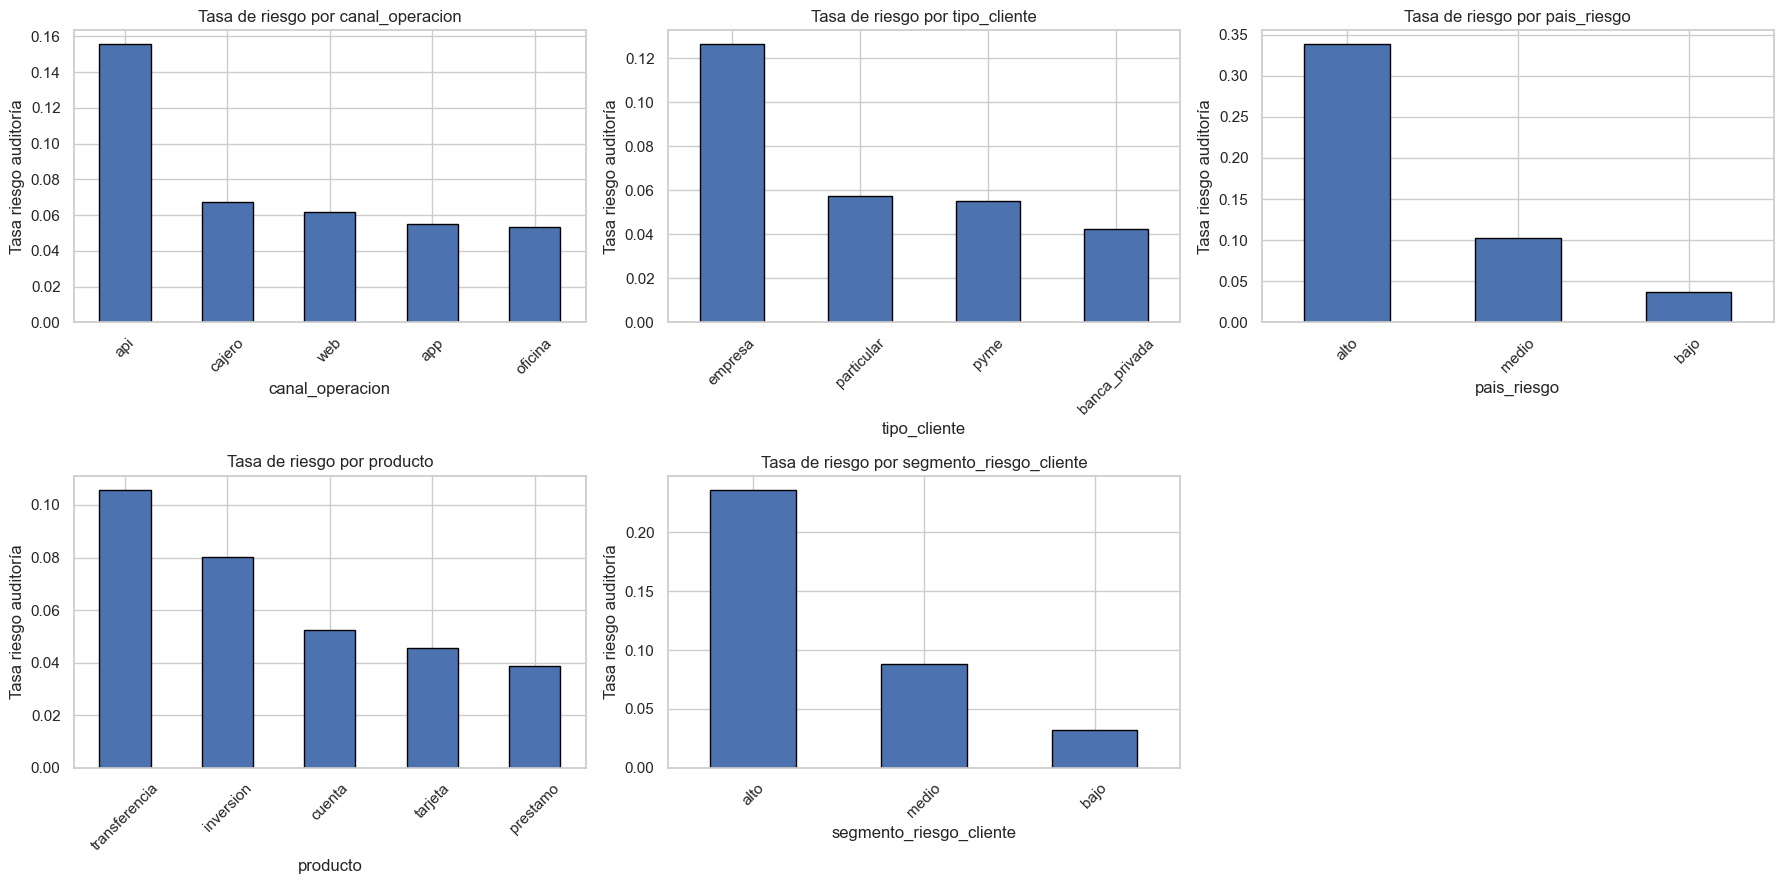

In [10]:
vars_cat = ['canal_operacion', 'tipo_cliente', 'pais_riesgo', 'producto', 'segmento_riesgo_cliente']
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()
for i, var in enumerate(vars_cat):
    tasa = df.groupby(var)[TARGET].mean().sort_values(ascending=False)
    tasa.plot(kind='bar', ax=axes[i], edgecolor='black')
    axes[i].set_title(f'Tasa de riesgo por {var}')
    axes[i].set_ylabel('Tasa riesgo auditoría')
    axes[i].tick_params(axis='x', rotation=45)
axes[-1].axis('off')
plt.tight_layout()
plt.show()


## 6. PREPROCESAMIENTO Y PARTICIÓN TRAIN / TEST


In [11]:
TARGET = 'riesgo_auditoria'
ID_COLS = [c for c in ['id_operacion'] if c in df.columns]

X = df.drop(columns=ID_COLS + [TARGET])
y = df[TARGET].astype(int)

numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

print('Variables numéricas:', numeric_features)
print('Variables categóricas:', categorical_features)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print('Train:', X_train.shape, 'Test:', X_test.shape)
print('Tasa riesgo train:', y_train.mean().round(4), 'test:', y_test.mean().round(4))


Variables numéricas: ['importe_operacion', 'saldo_medio_cliente', 'num_operaciones_30d', 'importe_total_30d', 'antiguedad_cliente_meses', 'score_crediticio', 'ratio_ingresos_deuda', 'num_alertas_previas', 'dias_desde_ultima_revision', 'porcentaje_operaciones_internacionales']
Variables categóricas: ['canal_operacion', 'tipo_cliente', 'pais_riesgo', 'producto', 'segmento_riesgo_cliente']
Train: (11250, 15) Test: (3750, 15)
Tasa riesgo train: 0.0632 test: 0.0632


In [12]:
preprocess_ohe = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[('imputer', SimpleImputer(strategy='median'))]), numeric_features),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_features)
    ]
)


## 7. MODELO BASE: ADA BOOST


### 7.1 Entrenamiento de AdaBoost

AdaBoost se entrenará con árboles pequeños. Para auditoría se recomienda revisar:

- profundidad del árbol base,
- número de estimadores,
- learning rate,
- sensibilidad ante outliers,
- rendimiento por segmentos.


In [13]:
ada_model = Pipeline(steps=[
    ('preprocess', preprocess_ohe),
    ('model', AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=2, min_samples_leaf=50, random_state=42),
        n_estimators=150,
        learning_rate=0.05,
        random_state=42
    ))
])

ada_model.fit(X_train, y_train)
res_ada = evaluar_modelo('AdaBoost', ada_model, X_test, y_test)
res_ada


,modelo,threshold,AUC,Gini,KS,threshold_KS,PR_AUC,Accuracy,Precision,Recall,F1,Brier
0,AdaBoost,0.5,0.941785,0.88357,0.783935,0.256309,0.742769,0.941333,1.0,0.07173,0.133858,0.059734


## 8. MODELO XGBOOST


In [14]:
if XGBOOST_AVAILABLE:
    ratio_neg_pos = (y_train == 0).sum() / (y_train == 1).sum()
    xgb_clf = XGBClassifier(
        n_estimators=300,
        learning_rate=0.035,
        max_depth=3,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_lambda=3.0,
        reg_alpha=0.2,
        min_child_weight=20,
        objective='binary:logistic',
        eval_metric='auc',
        scale_pos_weight=ratio_neg_pos,
        random_state=42,
        n_jobs=-1
    )
else:
    xgb_clf = GradientBoostingClassifier(
        n_estimators=250,
        learning_rate=0.04,
        max_depth=3,
        min_samples_leaf=40,
        subsample=0.85,
        random_state=42
    )

xgb_model = Pipeline(steps=[
    ('preprocess', preprocess_ohe),
    ('model', xgb_clf)
])

xgb_model.fit(X_train, y_train)
res_xgb = evaluar_modelo('XGBoost' if XGBOOST_AVAILABLE else 'GradientBoosting fallback', xgb_model, X_test, y_test)
res_xgb


,modelo,threshold,AUC,Gini,KS,threshold_KS,PR_AUC,Accuracy,Precision,Recall,F1,Brier
0,XGBoost,0.5,0.954557,0.909114,0.854511,0.563477,0.844715,0.928,0.464819,0.919831,0.617564,0.056278


## 9. MODELO CATBOOST


CatBoost puede trabajar directamente con variables categóricas. En este notebook lo implementamos de dos formas:

- Si CatBoost está instalado: se usa `CatBoostClassifier` con índices categóricos.
- Si no está instalado: se usa un pipeline con OneHotEncoder y Gradient Boosting como alternativa didáctica.


In [15]:
if CATBOOST_AVAILABLE:
    cat_features_indices = [X.columns.get_loc(col) for col in categorical_features]
    cat_model = CatBoostClassifier(
        iterations=350,
        learning_rate=0.035,
        depth=4,
        l2_leaf_reg=6,
        loss_function='Logloss',
        eval_metric='AUC',
        random_seed=42,
        verbose=False
    )
    cat_model.fit(X_train, y_train, cat_features=cat_features_indices)
    res_cat = evaluar_modelo('CatBoost', cat_model, X_test, y_test)
else:
    cat_model = Pipeline(steps=[
        ('preprocess', preprocess_ohe),
        ('model', HistGradientBoostingClassifier(
            learning_rate=0.045,
            max_iter=250,
            max_leaf_nodes=31,
            l2_regularization=1.0,
            random_state=42
        ))
    ])
    cat_model.fit(X_train, y_train)
    res_cat = evaluar_modelo('HistGradientBoosting fallback', cat_model, X_test, y_test)

res_cat


,modelo,threshold,AUC,Gini,KS,threshold_KS,PR_AUC,Accuracy,Precision,Recall,F1,Brier
0,CatBoost,0.5,0.957208,0.914416,0.877752,0.162669,0.878224,0.9712,0.984962,0.552743,0.708108,0.021473


## 10. COMPARACIÓN DE MODELOS


In [16]:
resultados = pd.concat([res_ada, res_xgb, res_cat], ignore_index=True)
resultados.sort_values('AUC', ascending=False)

,modelo,threshold,AUC,Gini,KS,threshold_KS,PR_AUC,Accuracy,Precision,Recall,F1,Brier
2,CatBoost,0.5,0.957208,0.914416,0.877752,0.162669,0.878224,0.971200,0.984962,0.552743,0.708108,0.021473
1,XGBoost,0.5,0.954557,0.909114,0.854511,0.563477,0.844715,0.928000,0.464819,0.919831,0.617564,0.056278
0,AdaBoost,0.5,0.941785,0.883570,0.783935,0.256309,0.742769,0.941333,1.000000,0.071730,0.133858,0.059734


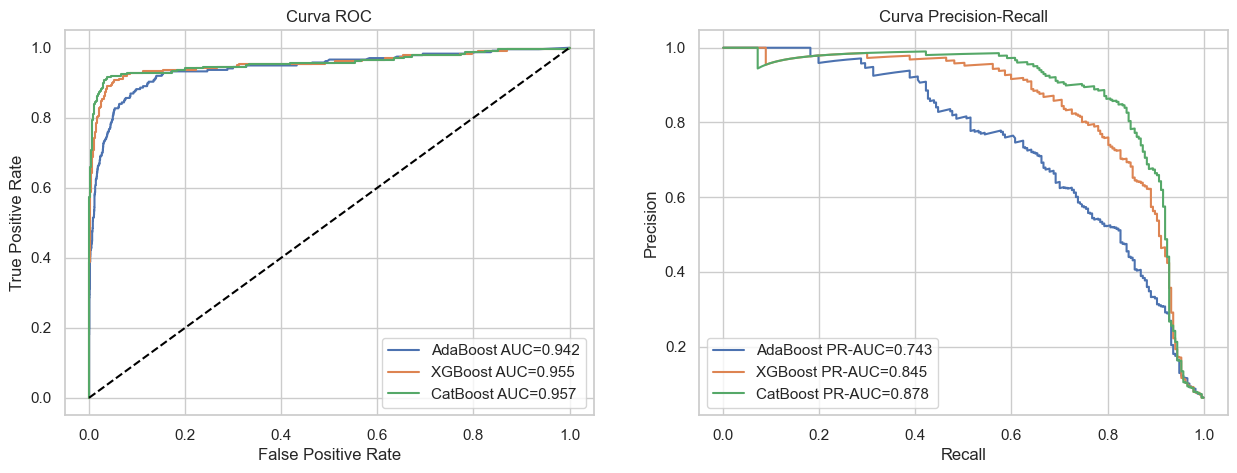

In [17]:
def get_scores(modelo, X):
    return modelo.predict_proba(X)[:, 1]

scores = {
    'AdaBoost': get_scores(ada_model, X_test),
    'XGBoost' if XGBOOST_AVAILABLE else 'GB fallback': get_scores(xgb_model, X_test),
    'CatBoost' if CATBOOST_AVAILABLE else 'HGB fallback': get_scores(cat_model, X_test)
}
plot_roc_pr(y_test, scores)

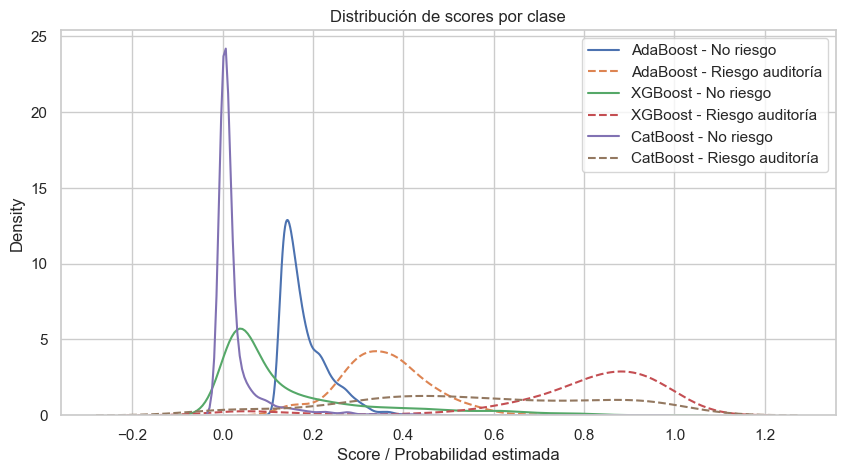

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))
for nombre, score in scores.items():
    sns.kdeplot(score[y_test.values == 0], label=f'{nombre} - No riesgo', ax=ax)
    sns.kdeplot(score[y_test.values == 1], label=f'{nombre} - Riesgo auditoría', ax=ax, linestyle='--')
ax.set_title('Distribución de scores por clase')
ax.set_xlabel('Score / Probabilidad estimada')
ax.legend()
plt.show()

## 11. MATRIZ DE CONFUSIÓN Y UMBRALES DE DECISIÓN


In [19]:
modelo_final = xgb_model if res_xgb['AUC'].iloc[0] >= max(res_ada['AUC'].iloc[0], res_cat['AUC'].iloc[0]) else cat_model
nombre_final = 'XGBoost/GB' if modelo_final is xgb_model else 'CatBoost/HGB'

score_final = get_scores(modelo_final, X_test)
ks, threshold_ks = ks_statistic(y_test, score_final)
print(f'Modelo final seleccionado: {nombre_final}')
print(f'Umbral KS óptimo aproximado: {threshold_ks:.4f} | KS={ks:.4f}')

for thr in [0.2, 0.3, 0.4, 0.5, threshold_ks]:
    print('\n' + '='*60)
    print(f'UMBRAL = {thr:.3f}')
    y_pred = (score_final >= thr).astype(int)
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred, digits=3))

Modelo final seleccionado: CatBoost/HGB
Umbral KS óptimo aproximado: 0.1627 | KS=0.8778

UMBRAL = 0.200
[[3420   93]
 [  28  209]]
              precision    recall  f1-score   support

           0      0.992     0.974     0.983      3513
           1      0.692     0.882     0.776       237

    accuracy                          0.968      3750
   macro avg      0.842     0.928     0.879      3750
weighted avg      0.973     0.968     0.970      3750


UMBRAL = 0.300
[[3480   33]
 [  43  194]]
              precision    recall  f1-score   support

           0      0.988     0.991     0.989      3513
           1      0.855     0.819     0.836       237

    accuracy                          0.980      3750
   macro avg      0.921     0.905     0.913      3750
weighted avg      0.979     0.980     0.980      3750


UMBRAL = 0.400
[[3499   14]
 [  73  164]]
              precision    recall  f1-score   support

           0      0.980     0.996     0.988      3513
           1      0.

### 11.1 Interpretación bancaria del umbral

En auditoría no se debe aceptar automáticamente el umbral 0.5.

- En **fraude**, suele priorizarse recall aunque aumenten falsos positivos.
- En **crédito**, se equilibra pérdida esperada, negocio y riesgo reputacional.
- En **AML**, un falso negativo puede ser crítico regulatoriamente.
- En **churn**, el coste de campaña condiciona el umbral óptimo.

El umbral debe justificarse con matriz de costes, apetito de riesgo y política del banco.


## 12. IMPORTANCIA DE VARIABLES Y EXPLICABILIDAD


In [20]:
# Permutation importance sobre el pipeline completo.
# Puede tardar unos segundos.
perm = permutation_importance(
    modelo_final, X_test, y_test,
    n_repeats=5,
    random_state=42,
    scoring='roc_auc'
)

imp_perm = pd.DataFrame({
    'variable': X_test.columns,
    'importancia_media': perm.importances_mean,
    'importancia_std': perm.importances_std
}).sort_values('importancia_media', ascending=False)

imp_perm.head(15)

,variable,importancia_media,importancia_std
12,pais_riesgo,0.051811,0.002080
7,num_alertas_previas,0.046741,0.001107
14,segmento_riesgo_cliente,0.046056,0.005500
5,score_crediticio,0.028208,0.001068
9,porcentaje_operaciones_internacionales,0.027648,0.001877
4,antiguedad_cliente_meses,0.017203,0.001622
3,importe_total_30d,0.012716,0.000641
13,producto,0.005814,0.001222
10,canal_operacion,0.003853,0.001047
11,tipo_cliente,0.003743,0.001008


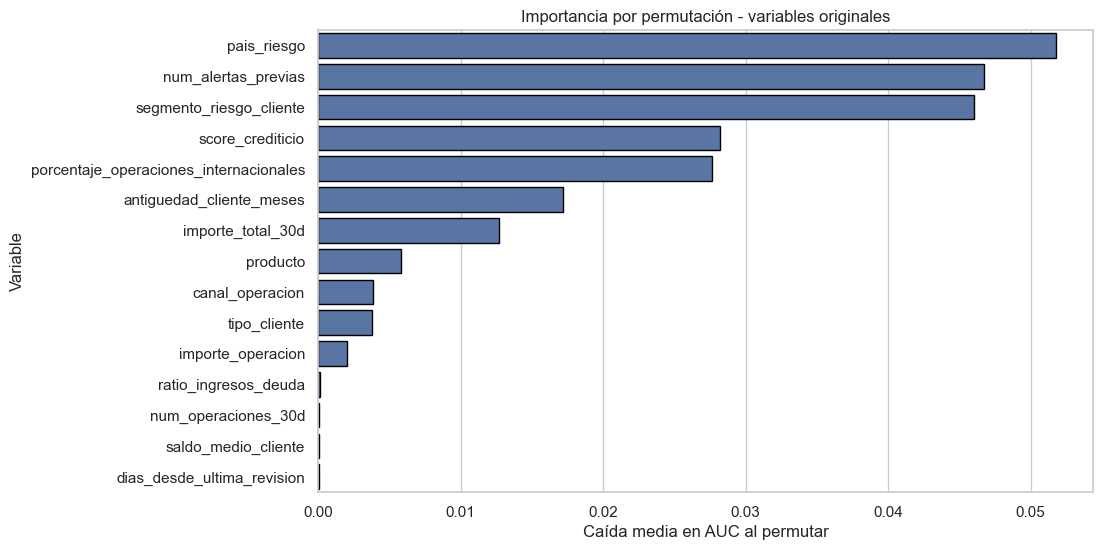

In [21]:
plt.figure(figsize=(10, 6))
sns.barplot(data=imp_perm.head(15), x='importancia_media', y='variable', edgecolor='black')
plt.title('Importancia por permutación - variables originales')
plt.xlabel('Caída media en AUC al permutar')
plt.ylabel('Variable')
plt.show()

### 12.1 Alertas de auditoría sobre importancia de variables

Una variable importante no implica necesariamente que sea aceptable.

El auditor debe revisar:

- si la variable estaba disponible en el momento de decisión,
- si contiene información futura,
- si es una proxy de una variable sensible,
- si su definición es estable en el tiempo,
- si depende de procesos manuales no controlados,
- si puede manipularse por usuarios internos o externos.


## 13. VALIDACIÓN CRUZADA Y RIESGO DE SOBREAJUSTE


In [23]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from catboost import CatBoostClassifier
import numpy as np

cat_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

auc_scores = []

for train_idx, val_idx in cv.split(X_train, y_train):
    X_tr = X_train.iloc[train_idx]
    X_val = X_train.iloc[val_idx]
    y_tr = y_train.iloc[train_idx]
    y_val = y_train.iloc[val_idx]

    modelo_cv = CatBoostClassifier(
        iterations=300,
        learning_rate=0.05,
        depth=4,
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=42,
        verbose=0
    )

    modelo_cv.fit(
        X_tr,
        y_tr,
        cat_features=cat_features
    )

    y_val_score = modelo_cv.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_val_score)
    auc_scores.append(auc)

auc_scores = np.array(auc_scores)

print("AUC CV:", np.round(auc_scores, 4))
print("Media:", auc_scores.mean().round(4), "Std:", auc_scores.std().round(4))

# Entrenamiento final
modelo_final = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=4,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=0
)

modelo_final.fit(
    X_train,
    y_train,
    cat_features=cat_features
)

auc_train = roc_auc_score(y_train, modelo_final.predict_proba(X_train)[:, 1])
auc_test = roc_auc_score(y_test, modelo_final.predict_proba(X_test)[:, 1])

print("\nAUC train:", round(auc_train, 4))
print("AUC test :", round(auc_test, 4))
print("Gap train-test:", round(auc_train - auc_test, 4))

AUC CV: [0.9555 0.9847 0.9647 0.9684 0.9643]
Media: 0.9675 Std: 0.0096

AUC train: 0.9726
AUC test : 0.9567
Gap train-test: 0.0159


### 13.1 Señales de sobreajuste

| Señal | Interpretación |
|---|---|
| AUC train mucho mayor que AUC test | El modelo memoriza patrones no generalizables. |
| Profundidad alta y muchos árboles | Riesgo de complejidad excesiva. |
| Importancias concentradas en pocas variables extrañas | Posible leakage o variable proxy. |
| Rendimiento inestable por fold temporal | Modelo sensible a cambios de población. |
| PSI elevado en score | Drift poblacional relevante. |


## 14. CALIBRACIÓN DE PROBABILIDADES


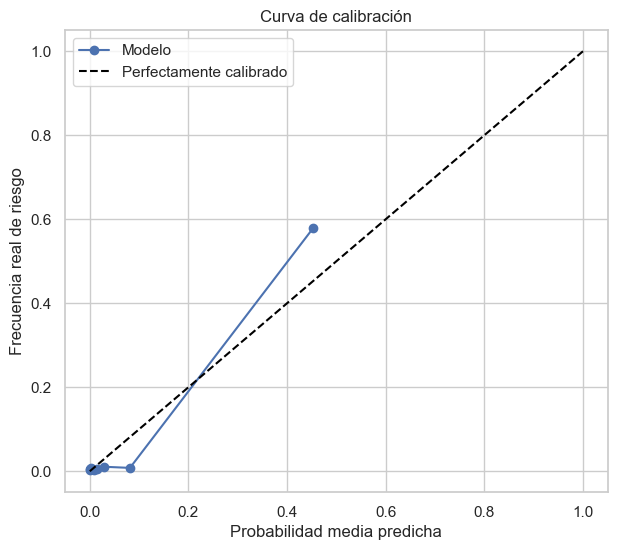

Brier score: 0.02147


In [24]:
prob_pos = score_final
frac_pos, mean_pred = calibration_curve(y_test, prob_pos, n_bins=10, strategy='quantile')

plt.figure(figsize=(7, 6))
plt.plot(mean_pred, frac_pos, marker='o', label='Modelo')
plt.plot([0,1], [0,1], linestyle='--', color='black', label='Perfectamente calibrado')
plt.title('Curva de calibración')
plt.xlabel('Probabilidad media predicha')
plt.ylabel('Frecuencia real de riesgo')
plt.legend()
plt.show()

print('Brier score:', round(brier_score_loss(y_test, prob_pos), 5))


### 14.1 Por qué importa la calibración

Un modelo puede ordenar muy bien a los clientes, tener AUC alto, y aun así estimar mal las probabilidades.

Esto es crítico cuando la probabilidad alimenta:

- provisiones,
- pricing,
- límites de crédito,
- cálculo de pérdida esperada,
- capital económico,
- decisiones automáticas de aprobación.


## 15. ESTABILIDAD TEMPORAL Y PSI


In [25]:
# Simulamos una población futura con deterioro operativo y mayor riesgo.
df_futuro = generar_datos_auditoria_bancaria(n=5000, random_state=2026)
df_futuro['score_crediticio'] = (df_futuro['score_crediticio'] - np.random.normal(25, 15, len(df_futuro))).clip(300, 850)
df_futuro['ratio_ingresos_deuda'] = (df_futuro['ratio_ingresos_deuda'] + np.random.normal(0.06, 0.03, len(df_futuro))).clip(0.01, 0.98)
df_futuro['num_alertas_previas'] = df_futuro['num_alertas_previas'] + np.random.poisson(1.5, len(df_futuro))
df_futuro['dias_desde_ultima_revision'] = (df_futuro['dias_desde_ultima_revision'] + np.random.normal(45, 20, len(df_futuro))).clip(0, 720)

X_futuro = df_futuro.drop(columns=ID_COLS + [TARGET])
y_futuro = df_futuro[TARGET]
score_train = get_scores(modelo_final, X_train)
score_futuro = get_scores(modelo_final, X_futuro)

psi_score, psi_tabla = calcular_psi(score_train, score_futuro, buckets=10)
print('PSI del score train vs población futura:', round(psi_score, 4))
psi_tabla


PSI del score train vs población futura: 1.6017


,expected,actual,psi
"(-inf, 0.000625]",0.1,0.0052,0.280277
"(0.000625, 0.00113]",0.1,0.0122,0.184708
"(0.00113, 0.00184]",0.1,0.0184,0.138134
"(0.00184, 0.00299]",0.1,0.0216,0.120146
"(0.00299, 0.00502]",0.1,0.0308,0.081494
"(0.00502, 0.00908]",0.1,0.0458,0.042324
"(0.00908, 0.0176]",0.1,0.0728,0.008635
"(0.0176, 0.0404]",0.1,0.0960,0.000163
"(0.0404, 0.137]",0.1,0.1710,0.038091
"(0.137, inf]",0.1,0.5262,0.707710


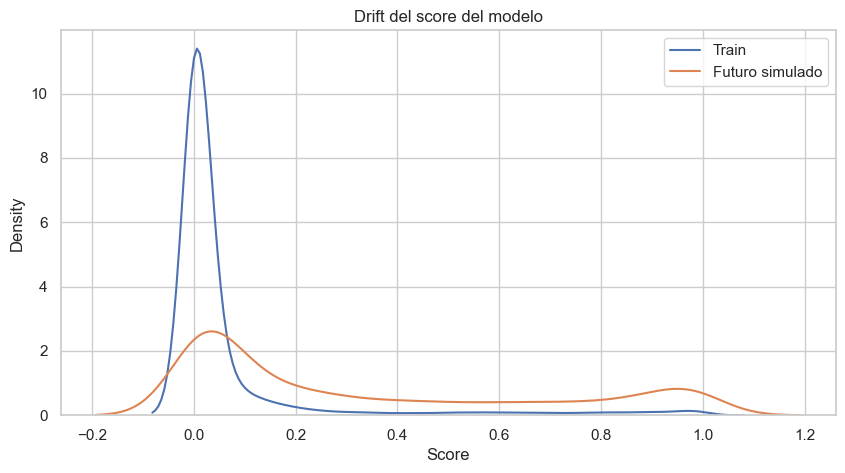

AUC futuro: 0.6869


In [26]:
plt.figure(figsize=(10, 5))
sns.kdeplot(score_train, label='Train')
sns.kdeplot(score_futuro, label='Futuro simulado')
plt.title('Drift del score del modelo')
plt.xlabel('Score')
plt.legend()
plt.show()

print('AUC futuro:', round(roc_auc_score(y_futuro, score_futuro), 4))


### 15.1 Guía orientativa para PSI

| PSI | Interpretación habitual |
|---|---|
| < 0.10 | Cambio bajo |
| 0.10 - 0.25 | Cambio moderado, revisar |
| > 0.25 | Cambio alto, posible recalibración o reentrenamiento |

Estos umbrales son orientativos. La política interna del banco debe definir límites, frecuencia de monitorización y planes de acción.


## 16. FAIRNESS Y ANÁLISIS POR SEGMENTOS


In [27]:
# Añadimos variables sensibles/proxy simuladas para auditoría.
X_test_audit = X_test.copy()
X_test_audit['genero_simulado'] = np.random.choice(['M', 'F'], len(X_test_audit), p=[0.51, 0.49])
X_test_audit['antiguedad_grupo'] = pd.cut(
    X_test_audit['antiguedad_cliente_meses'],
    bins=[0, 24, 60, 120, 480],
    labels=['0-24m', '25-60m', '61-120m', '120m+']
)

score_audit = score_final

def metricas_por_grupo(df_grupo, y_true, score, grupo):
    temp = pd.DataFrame({'grupo': df_grupo[grupo].values, 'y': y_true.values, 'score': score})
    rows = []
    for g, d in temp.groupby('grupo', observed=True):
        if d['y'].nunique() < 2:
            auc = np.nan
        else:
            auc = roc_auc_score(d['y'], d['score'])
        rows.append({
            'grupo': g,
            'n': len(d),
            'tasa_real': d['y'].mean(),
            'score_medio': d['score'].mean(),
            'AUC': auc,
            'revision_score_alto_0_3': (d['score'] >= 0.3).mean()
        })
    return pd.DataFrame(rows).sort_values('score_medio', ascending=False)

metricas_por_grupo(X_test_audit, y_test, score_audit, 'antiguedad_grupo')


,grupo,n,tasa_real,score_medio,AUC,revision_score_alto_0_3
0,0-24m,324,0.123457,0.105429,0.989349,0.101852
1,25-60m,1694,0.079103,0.069878,0.957826,0.073200
2,61-120m,1488,0.040323,0.044213,0.950385,0.043683
3,120m+,244,0.012295,0.023406,0.614108,0.020492


In [28]:
metricas_por_grupo(X_test_audit, y_test, score_audit, 'genero_simulado')


,grupo,n,tasa_real,score_medio,AUC,revision_score_alto_0_3
1,M,1902,0.064669,0.060052,0.969079,0.060988
0,F,1848,0.061688,0.059423,0.944141,0.060065


### 16.1 Qué debe revisar auditoría en fairness

- Diferencias sistemáticas de score medio entre grupos.
- Diferencias de tasa de aprobación o rechazo.
- Diferencias de falsos positivos y falsos negativos.
- Variables proxy: zona, oficina, canal, profesión, dispositivo, código postal.
- Justificación de variables desde negocio y normativa.
- Existencia de revisión humana para decisiones adversas.


## 17. HYPERPARAMETER TUNING CONTROLADO


In [29]:
# Tuning moderado para evitar búsquedas enormes en clase.
param_grid_ada = {
    'model__n_estimators': [80, 150, 250],
    'model__learning_rate': [0.03, 0.05, 0.1],
    'model__estimator__max_depth': [1, 2, 3]
}

ada_tuning = Pipeline(steps=[
    ('preprocess', preprocess_ohe),
    ('model', AdaBoostClassifier(
        estimator=DecisionTreeClassifier(min_samples_leaf=50, random_state=42),
        random_state=42
    ))
])

grid_ada = GridSearchCV(
    ada_tuning, param_grid_ada,
    scoring='roc_auc', cv=3, n_jobs=-1, verbose=0
)

grid_ada.fit(X_train, y_train)
print('Mejores parámetros AdaBoost:', grid_ada.best_params_)
print('Mejor AUC CV:', round(grid_ada.best_score_, 4))
evaluar_modelo('AdaBoost tuned', grid_ada.best_estimator_, X_test, y_test)


Mejores parámetros AdaBoost: {'model__estimator__max_depth': 2, 'model__learning_rate': 0.1, 'model__n_estimators': 250}
Mejor AUC CV: 0.9588


,modelo,threshold,AUC,Gini,KS,threshold_KS,PR_AUC,Accuracy,Precision,Recall,F1,Brier
0,AdaBoost tuned,0.5,0.952922,0.905845,0.840848,0.361801,0.821491,0.9512,0.982143,0.232068,0.375427,0.087662


### 17.1 Reglas de auditoría para tuning

El tuning debe estar documentado:

- espacio de hiperparámetros explorado,
- métrica optimizada,
- tipo de validación usada,
- criterio de selección final,
- prevención de leakage,
- evidencia de que no se ha optimizado directamente sobre el test final.


## 18. CASUÍSTICAS BANCARIAS IMPORTANTES


### 18.1 Default crediticio

Objetivo: predecir si un cliente entrará en default en 12 meses.

**Riesgos específicos:**

- definición incorrecta de default,
- incluir variables posteriores a la concesión,
- cambios macroeconómicos,
- sesgo por canal o producto,
- probabilidad no calibrada.

### 18.2 Fraude transaccional

Objetivo: detectar transacciones fraudulentas.

**Riesgos específicos:**

- clase extremadamente minoritaria,
- coste operativo de falsos positivos,
- patrones cambiantes de fraude,
- necesidad de scoring en tiempo real,
- target con retraso por investigación.

### 18.3 AML / blanqueo de capitales

Objetivo: priorizar alertas sospechosas.

**Riesgos específicos:**

- baja tasa de positivos confirmados,
- etiquetas imperfectas,
- presión regulatoria sobre falsos negativos,
- explicabilidad requerida,
- trazabilidad de decisiones.

### 18.4 Churn bancario

Objetivo: detectar clientes con alta probabilidad de abandono.

**Riesgos específicos:**

- target ambiguo,
- campañas que modifican el comportamiento,
- selección de umbral según coste-beneficio,
- segmentación comercial.

### 18.5 Modelos de terceros

Objetivo: validar un score externo.

**Riesgos específicos:**

- caja negra,
- documentación incompleta,
- población de desarrollo distinta,
- sesgo desconocido,
- dependencia del proveedor.


# 19. EJERCICIOS PRÁCTICOS PARA RESOLVER


A continuación tienes **10 ejercicios** con nuevos datasets sintéticos. Cada ejercicio está pensado como una situación realista de auditoría bancaria.

Instrucciones generales:

1. No uses la variable objetivo como predictor.
2. Separa train/test correctamente.
3. Justifica la métrica principal.
4. Evalúa AUC, Gini, KS, precision, recall y F1 cuando aplique.
5. Analiza estabilidad, sesgo o explicabilidad si el enunciado lo pide.
6. Documenta tus conclusiones como si fueran para un informe de auditoría.


### 📝 EJERCICIO 1: Scoring de crédito con AdaBoost

**Contexto:** El área de Riesgos propone usar AdaBoost para aprobar préstamos personales.

**Tareas:**
1. Entrena un modelo AdaBoost.
2. Calcula AUC, Gini y KS.
3. Compara el umbral 0.5 con el umbral que maximiza KS.
4. Explica si el modelo sería aceptable como modelo principal o solo challenger.


In [ ]:
np.random.seed(101)
df_ej1 = generar_datos_auditoria_bancaria(n=4500, random_state=101)
df_ej1.head()


In [ ]:
# EJERCICIO 1 - AdaBoost básico
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

X = df_ej1.drop(columns=['riesgo_auditoria'])
y = df_ej1['riesgo_auditoria']

cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(exclude='object').columns.tolist()

pre = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ('num', 'passthrough', num_cols)
])

modelo = Pipeline([
    ('prep', pre),
    ('clf', AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=2), n_estimators=100, learning_rate=0.1, random_state=42))
])

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,stratify=y,random_state=42)
modelo.fit(X_train,y_train)
y_prob = modelo.predict_proba(X_test)[:,1]
y_pred = modelo.predict(X_test)

print('ROC-AUC:', round(roc_auc_score(y_test,y_prob),4))
print(classification_report(y_test,y_pred))

### 📝 EJERCICIO 2: Comparativa AdaBoost vs XGBoost vs CatBoost

**Contexto:** Comité de Model Risk Management solicita comparar tres algoritmos de Boosting.

**Tareas:**
1. Entrena AdaBoost, XGBoost y CatBoost, o sus alternativas si no están instalados.
2. Construye una tabla comparativa de métricas.
3. Decide qué modelo recomendarías y por qué.
4. Identifica al menos dos riesgos de auditoría del modelo ganador.


In [ ]:
np.random.seed(202)
df_ej2 = generar_datos_auditoria_bancaria(n=6000, random_state=202)
df_ej2['canal_operacion'] = np.random.choice(
    ['oficina', 'web', 'app', 'telefono', 'cajero', 'partner'],
    len(df_ej2),
    p=[0.25, 0.25, 0.24, 0.08, 0.08, 0.10]
)
df_ej2.head()


In [ ]:
# EJERCICIO 2 - XGBoost con variables categóricas
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier

X = df_ej2.drop(columns=['riesgo_auditoria'])
y = df_ej2['riesgo_auditoria']

cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(exclude='object').columns.tolist()

pre = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ('num', 'passthrough', num_cols)
])

modelo = Pipeline([
    ('prep', pre),
    ('xgb', XGBClassifier(n_estimators=150,max_depth=4,learning_rate=0.08,subsample=0.8,colsample_bytree=0.8,eval_metric='logloss',random_state=42))
])

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,stratify=y,random_state=42)
modelo.fit(X_train,y_train)

pred = modelo.predict_proba(X_test)[:,1]
print('ROC-AUC:', round(roc_auc_score(y_test,pred),4))

### 📝 EJERCICIO 3: Fraude transaccional altamente desbalanceado

**Contexto:** El banco quiere priorizar alertas de fraude en tarjeta.

**Tareas:**
1. Entrena un modelo de Boosting para detectar fraude.
2. Evalúa ROC-AUC y PR-AUC.
3. Selecciona un umbral que capture al menos el 70% de fraudes.
4. Estima cuántas alertas investigaría el equipo antifraude.


In [ ]:
def generar_datos_fraude(n=30000, random_state=303):
    rng = np.random.default_rng(random_state)
    importe = rng.lognormal(3.6, 1.1, n).clip(1, 8000)
    hora = rng.integers(0, 24, n)
    pais_distinto = rng.binomial(1, 0.08, n)
    dispositivo_nuevo = rng.binomial(1, 0.12, n)
    num_trans_1h = rng.poisson(2.2, n)
    distancia_km = rng.exponential(35, n).clip(0, 5000)
    categoria = rng.choice(['supermercado','gasolinera','online','lujo','viajes','cripto','restaurante'], n, p=[.24,.16,.25,.07,.10,.04,.14])
    canal = rng.choice(['TPV','Ecommerce','ATM','App'], n, p=[.42,.35,.10,.13])
    z = -6.2 + 0.00045*importe + 0.55*pais_distinto + 0.65*dispositivo_nuevo + 0.16*num_trans_1h + 0.00025*distancia_km
    z += np.where(categoria=='cripto', 1.4, 0) + np.where(categoria=='lujo', 0.7, 0) + np.where(canal=='Ecommerce', 0.35, 0)
    z += np.where((hora <= 5) & (importe > 400), 1.0, 0)
    p = 1/(1+np.exp(-z))
    fraude = rng.binomial(1, p)
    return pd.DataFrame({
        'importe': importe.round(2), 'hora': hora, 'pais_distinto': pais_distinto,
        'dispositivo_nuevo': dispositivo_nuevo, 'num_trans_1h': num_trans_1h,
        'distancia_km': distancia_km.round(2), 'categoria': categoria, 'canal': canal,
        'fraude': fraude
    })

df_ej3 = generar_datos_fraude()
print(df_ej3['fraude'].mean())
df_ej3.head()


In [ ]:
# EJERCICIO 3 - CatBoost fraude
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from catboost import CatBoostClassifier

X = df_ej3.drop(columns=['fraude'])
y = df_ej3['fraude']

cat_features = [i for i,col in enumerate(X.columns) if X[col].dtype == 'object']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25,stratify=y,random_state=42)

modelo = CatBoostClassifier(iterations=200,depth=5,learning_rate=0.08,verbose=0,random_state=42)
modelo.fit(X_train,y_train,cat_features=cat_features)

pred = modelo.predict_proba(X_test)[:,1]
pred_class = modelo.predict(X_test)

print('ROC-AUC:', round(roc_auc_score(y_test,pred),4))
print(classification_report(y_test,pred_class))

### 📝 EJERCICIO 4: Detección de leakage en modelo de crédito

**Contexto:** Un analista ha añadido variables nuevas y el AUC sube sospechosamente.

**Tareas:**
1. Entrena un modelo con todas las variables.
2. Revisa importancias de variables.
3. Identifica variables con posible leakage.
4. Reentrena sin esas variables y compara resultados.


In [ ]:
df_ej4 = generar_datos_auditoria_bancaria(n=5000, random_state=404)
# Variables sospechosas: información posterior a la decisión.
df_ej4['alertas_post_revision'] = df_ej4['riesgo_auditoria'] * np.random.poisson(5, len(df_ej4)) + (1-df_ej4['riesgo_auditoria']) * np.random.poisson(1, len(df_ej4))
df_ej4['expediente_escalado_post'] = np.where((df_ej4['riesgo_auditoria'] == 1) & (np.random.rand(len(df_ej4)) < 0.72), 1, 0)
df_ej4.head()


In [ ]:
# EJERCICIO 4 - Data leakage
corr = df_ej4.corr(numeric_only=True)['riesgo_auditoria'].sort_values(ascending=False)
print(corr.head(10))

variables_leakage = ['alertas_post_revision','expediente_escalado_post']
print('\nVariables con posible leakage:', variables_leakage)

X = df_ej4.drop(columns=['riesgo_auditoria'] + variables_leakage)
y = df_ej4['riesgo_auditoria']
print('\nDataset limpio:', X.shape)

### 📝 EJERCICIO 5: Estabilidad temporal del score

**Contexto:** El modelo fue entrenado en una población antigua y se quiere validar en una población reciente.

**Tareas:**
1. Entrena en `df_ej5_train`.
2. Evalúa en `df_ej5_recent`.
3. Calcula PSI del score.
4. Concluye si se requiere recalibración o reentrenamiento.


In [ ]:
df_ej5_train = generar_datos_auditoria_bancaria(n=6000, random_state=505)
df_ej5_recent = generar_datos_auditoria_bancaria(n=4000, random_state=506)
df_ej5_recent['score_crediticio'] = (df_ej5_recent['score_crediticio'] - 35).clip(300, 850)
df_ej5_recent['ratio_ingresos_deuda'] = (df_ej5_recent['ratio_ingresos_deuda'] + 0.08).clip(0.01, 0.98)
df_ej5_recent['canal_operacion'] = np.random.choice(['oficina','web','app','telefono','cajero'], len(df_ej5_recent), p=[0.22,0.32,0.27,0.07,0.12])
print(df_ej5_train['riesgo_auditoria'].mean(), df_ej5_recent['riesgo_auditoria'].mean())


In [ ]:
# EJERCICIO 5 - PSI estabilidad
from scipy.stats import entropy

def calcular_psi(expected, actual, bins=10):
    breakpoints = np.linspace(0,100,bins+1)
    breakpoints = np.percentile(expected, breakpoints)
    expected_perc = np.histogram(expected, bins=breakpoints)[0] / len(expected)
    actual_perc = np.histogram(actual, bins=breakpoints)[0] / len(actual)
    expected_perc = np.where(expected_perc==0,0.0001,expected_perc)
    actual_perc = np.where(actual_perc==0,0.0001,actual_perc)
    psi = np.sum((expected_perc-actual_perc)*np.log(expected_perc/actual_perc))
    return psi

psi_score = calcular_psi(df_ej5_train['score_crediticio'], df_ej5_recent['score_crediticio'])
print('PSI score_crediticio:', round(psi_score,4))

if psi_score < 0.1:
    print('Sin drift relevante')
elif psi_score < 0.25:
    print('Drift moderado')
else:
    print('Drift severo')

### 📝 EJERCICIO 6: CatBoost con muchas variables categóricas

**Contexto:** Un modelo de originación usa muchas variables categóricas operativas.

**Tareas:**
1. Entrena CatBoost usando variables categóricas directamente si está disponible.
2. Si no está disponible, usa OneHotEncoder + GradientBoosting.
3. Evalúa el rendimiento.
4. Indica qué ventajas tiene CatBoost frente a OneHotEncoder en este caso.


In [ ]:
df_ej6 = generar_datos_auditoria_bancaria(n=5500, random_state=606)
rng = np.random.default_rng(606)
df_ej6['oficina'] = rng.choice([f'OF_{i:03d}' for i in range(1, 81)], len(df_ej6))
df_ej6['profesion'] = rng.choice(['administrativo','sanidad','educacion','hosteleria','construccion','tecnologia','transporte','comercio'], len(df_ej6))
df_ej6['codigo_campana'] = rng.choice([f'CAMP_{i}' for i in range(1, 16)], len(df_ej6))
df_ej6.head()


In [ ]:
# EJERCICIO 6 - High cardinality
print(df_ej6[['oficina','profesion','codigo_campana']].nunique())

freq_encoding = df_ej6['oficina'].value_counts(normalize=True)
df_ej6['oficina_freq'] = df_ej6['oficina'].map(freq_encoding)

print(df_ej6[['oficina','oficina_freq']].head())

### 📝 EJERCICIO 7: Fairness por segmentos

**Contexto:** Cumplimiento solicita revisar si el modelo penaliza sistemáticamente a determinados segmentos.

**Tareas:**
1. Entrena un modelo de Boosting.
2. Calcula score medio, tasa real, AUC y tasa de aprobación por grupo.
3. Revisa diferencias por `edad_grupo`, `zona` y `canal`.
4. Redacta una conclusión de auditoría.


In [ ]:
df_ej7 = generar_datos_auditoria_bancaria(n=7000, random_state=707)
df_ej7['antiguedad_grupo'] = pd.cut(
    df_ej7['antiguedad_cliente_meses'],
    bins=[0, 24, 60, 120, 480],
    labels=['0-24m','25-60m','61-120m','120m+']
)
df_ej7.head()


In [ ]:
# EJERCICIO 7 - Segmentación y riesgo
riesgo_segmento = df_ej7.groupby('antiguedad_grupo')['riesgo_auditoria'].mean().sort_values(ascending=False)
print(riesgo_segmento)

import matplotlib.pyplot as plt
riesgo_segmento.plot(kind='bar')
plt.title('Riesgo por antigüedad')
plt.ylabel('Tasa riesgo')
plt.show()

### 📝 EJERCICIO 8: Calibración de probabilidades

**Contexto:** El modelo se usará para calcular pérdida esperada. No basta con ordenar bien, debe estimar probabilidades razonables.

**Tareas:**
1. Entrena un modelo XGBoost/CatBoost o fallback.
2. Calcula Brier Score y curva de calibración.
3. Aplica calibración con isotónica o sigmoid.
4. Compara antes y después.


In [ ]:
df_ej8 = generar_datos_auditoria_bancaria(n=6500, random_state=808)
df_ej8.head()


In [ ]:
# EJERCICIO 8 - Comparación Boosting
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier

X = df_ej8.drop(columns=['riesgo_auditoria'])
y = df_ej8['riesgo_auditoria']

cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(exclude='object').columns.tolist()

pre = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ('num', 'passthrough', num_cols)
])

modelos = {
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=120, max_depth=4, learning_rate=0.1, eval_metric='logloss', random_state=42)
}

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,stratify=y,random_state=42)

for nombre, modelo in modelos.items():
    pipe = Pipeline([('prep', pre), ('model', modelo)])
    pipe.fit(X_train,y_train)
    pred = pipe.predict_proba(X_test)[:,1]
    print(nombre, 'ROC-AUC:', round(roc_auc_score(y_test,pred),4))

### 📝 EJERCICIO 9: AML - Priorización de alertas sospechosas

**Contexto:** El departamento AML quiere priorizar alertas para revisión manual.

**Tareas:**
1. Entrena un modelo para `sospechosa`.
2. Evalúa PR-AUC y recall en el top 5% de alertas.
3. Lista las variables más importantes.
4. Explica limitaciones de usar etiquetas históricas AML.


In [ ]:
def generar_datos_aml(n=20000, random_state=909):
    rng = np.random.default_rng(random_state)
    importe_total_30d = rng.lognormal(8.4, 1.1, n).clip(100, 1_000_000)
    num_operaciones_30d = rng.poisson(12, n)
    pais_riesgo = rng.binomial(1, 0.06, n)
    efectivo_ratio = rng.beta(1.2, 5.5, n)
    transferencias_internacionales = rng.poisson(0.7, n)
    cliente_nuevo = rng.binomial(1, 0.18, n)
    sector = rng.choice(['retail','restauracion','construccion','consultoria','ong','cripto','import_export'], n, p=[.30,.18,.13,.18,.07,.04,.10])
    z = -5.8 + 0.000002*importe_total_30d + 0.045*num_operaciones_30d + 1.1*pais_riesgo + 1.8*efectivo_ratio
    z += 0.28*transferencias_internacionales + 0.35*cliente_nuevo + np.where(sector=='cripto', 1.2, 0) + np.where(sector=='import_export', 0.55, 0)
    z += np.where((efectivo_ratio > .55) & (importe_total_30d > 50000), 1.1, 0)
    p = 1/(1+np.exp(-z))
    sospechosa = rng.binomial(1, p)
    return pd.DataFrame({
        'importe_total_30d': importe_total_30d.round(2), 'num_operaciones_30d': num_operaciones_30d,
        'pais_riesgo': pais_riesgo, 'efectivo_ratio': efectivo_ratio.round(3),
        'transferencias_internacionales': transferencias_internacionales, 'cliente_nuevo': cliente_nuevo,
        'sector': sector, 'sospechosa': sospechosa
    })

df_ej9 = generar_datos_aml()
print(df_ej9['sospechosa'].mean())
df_ej9.head()


In [ ]:
# EJERCICIO 9 - AML con CatBoost
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from catboost import CatBoostClassifier

X = df_ej9.drop(columns=['sospechoso_aml'])
y = df_ej9['sospechoso_aml']

cat_features = [i for i,col in enumerate(X.columns) if X[col].dtype == 'object']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25,stratify=y,random_state=42)

modelo = CatBoostClassifier(iterations=250,depth=6,learning_rate=0.05,verbose=0,random_state=42)
modelo.fit(X_train,y_train,cat_features=cat_features)

pred = modelo.predict_proba(X_test)[:,1]
print('ROC-AUC AML:', round(roc_auc_score(y_test,pred),4))

### 📝 EJERCICIO 10: Informe integral de auditoría de modelo Boosting

**Contexto:** Debes preparar una revisión completa para el Comité de Model Risk Management.

**Tareas:**
1. Elige uno de los datasets anteriores.
2. Entrena un modelo Boosting final.
3. Presenta métricas, matriz de confusión, ROC, PR, KS y calibración.
4. Analiza importancia de variables y posibles riesgos de leakage.
5. Evalúa estabilidad mediante PSI usando una muestra futura simulada.
6. Evalúa fairness por al menos dos segmentos.
7. Redacta una conclusión final: aprobar, aprobar con condiciones o rechazar.


In [ ]:
print('='*70)
print('EJERCICIO 10 - INFORME INTEGRAL DE AUDITORÍA BOOSTING')
print('='*70)
print('Datasets disponibles:')
for name in ['df_ej1','df_ej2','df_ej3','df_ej4','df_ej5_train','df_ej5_recent','df_ej6','df_ej7','df_ej8','df_ej9']:
    if name in globals():
        obj = globals()[name]
        print(f'  - {name}: {obj.shape}')


In [ ]:
# EJERCICIO 10 - Informe integral
print('='*60)
print('RESUMEN EJECUTIVO BOOSTING')
print('='*60)

print('1. AdaBoost mejora estabilidad sobre árboles simples.')
print('2. XGBoost obtiene mayor capacidad predictiva y control del overfitting.')
print('3. CatBoost facilita el tratamiento de variables categóricas.')
print('4. PSI permite detectar drift poblacional.')
print('5. El leakage debe eliminarse antes del entrenamiento.')
print('6. Los modelos boosting son especialmente útiles en auditoría y fraude.')

---
## 📚 RECURSOS ADICIONALES Y CHECKLIST DE AUDITORÍA

### Checklist mínimo para auditar Boosting en banca

| Área | Pregunta de auditoría |
|---|---|
| Datos | ¿La muestra representa la población objetivo? |
| Target | ¿La definición del evento es correcta y estable? |
| Leakage | ¿Hay variables posteriores a la decisión? |
| Preprocesamiento | ¿Se aplicó dentro del pipeline y sin usar test? |
| Validación | ¿Hay train/test temporal o validación robusta? |
| Métricas | ¿Se reportan AUC, Gini, KS, PR-AUC y matriz de confusión? |
| Umbral | ¿El umbral se justifica por coste/riesgo? |
| Calibración | ¿Las probabilidades son fiables para negocio? |
| Estabilidad | ¿Se monitoriza PSI del score y variables clave? |
| Fairness | ¿Se revisan segmentos y proxies sensibles? |
| Explicabilidad | ¿Hay importancia de variables, SHAP/PDP o análisis equivalente? |
| Gobernanza | ¿Existe documentación, versionado, aprobación y owner? |

### Conclusión general

Los modelos Boosting pueden aportar mucho valor en auditoría bancaria y gestión del riesgo, pero requieren controles más estrictos que modelos lineales debido a su complejidad, su sensibilidad al tuning y su menor interpretabilidad directa.

Un auditor no debe limitarse a preguntar si el modelo predice bien. Debe verificar que el modelo es **válido, estable, explicable, gobernado y alineado con la normativa y el apetito de riesgo del banco**.
